# LangGraph Fundamentals & State Management

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


### Simple Workflow

Input → Process → Output

In [8]:
class State(TypedDict):
    text: str

def process(state):
    state["text"] = state["text"].title()
    return state

builder = StateGraph(State)
builder.add_node("process", process)
builder.add_edge(START, "process")
builder.add_edge("process", END)
graph = builder.compile()
result = graph.invoke({"text": "langgraph fundamentals and state management"})
print(result)
graph_builder = StateGraph(State)

{'text': 'Langgraph Fundamentals And State Management'}


In [4]:
png = graph.get_graph().draw_mermaid_png()

with open("graph.png", "wb") as f:
    f.write(png)

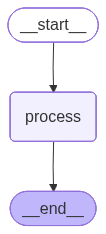

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Conditional Routing

In [10]:
class State(TypedDict):
    number: int
    result: str

builder = StateGraph(State)

def check_number(state):
    return state

builder.add_edge(START, "check")
def route(state):
    num = state["number"]
    if num < 2:
        return "not_prime"
    for i in range(2, int(num**0.5) + 1):
        if num % i == 0:
            return "not_prime"
    return "prime"

def prime_node(state):
    state["result"] = f"{state['number']} is a prime number"
    return state

def not_prime_node(state):
    state["result"] = f"{state['number']} is not a prime number"
    return state

builder.add_node("check", check_number)
builder.add_node("prime_node", prime_node)
builder.add_node("not_prime_node", not_prime_node)

builder.add_conditional_edges(
    "check",
    route,
    {
        "prime": "prime_node",
        "not_prime": "not_prime_node"
    }
)

builder.add_edge("prime_node", END)
builder.add_edge("not_prime_node", END)

graph = builder.compile()
result = graph.invoke({"number": 17})
print(result)

{'number': 17, 'result': '17 is a prime number'}


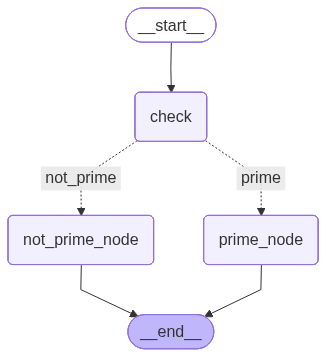

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Loop Workflow

Retry until successful

In [ ]:
class State(TypedDict):
    password: str
    valid: bool
    attempts: int

def validate_password(state):
    password = state["password"]
    state["attempts"] += 1
    has_digit = any(char.isdigit() for char in password)
    if len(password) >= 8 and has_digit:
        state["valid"] = True
    else:
        state["valid"] = False
    return state

def route_password(state):
    if state["valid"]:
        return "end"
    new_password = input("Password invalid. Enter a new password: ")
    state["password"] = new_password
    return "retry"

builder = StateGraph(State)

builder.add_node("validate",validate_password)
builder.add_edge(START,"validate")
builder.add_conditional_edges(
    "validate",
    route_password,
    {
        "retry": "validate",
        "end": END
    }
)

graph = builder.compile()
result = graph.invoke(
    {
        "password": "abcd",
        "valid": False,
        "attempts": 0
    }
)
print(result)

In [3]:
class State(TypedDict):
    password: str
    valid: bool
    attempts: int

def validate_password(state: State):
    password = state["password"]
    has_digit = any(char.isdigit() for char in password)
    is_valid = len(password) >= 8 and has_digit
    return {
        "valid": is_valid,
        "attempts": state["attempts"] + 1
    }

def ask_for_new_password(state: State):
    new_password = input("Password invalid. Enter a new password: ")
    return {"password": new_password}

def route_password(state: State):
    if state["valid"]:
        return "end"
    return "retry"

builder = StateGraph(State)

builder.add_node("validate", validate_password)
builder.add_node("ask_new", ask_for_new_password)
builder.add_edge(START, "validate")
builder.add_conditional_edges(
    "validate",
    route_password,
    {
        "retry": "ask_new",  
        "end": END           
    }
)

builder.add_edge("ask_new", "validate")
graph = builder.compile()
result = graph.invoke(
    {
        "password": "abcd",
        "valid": False,
        "attempts": 0
    }
)
print(result)


{'password': 'abcd12345', 'valid': True, 'attempts': 3}


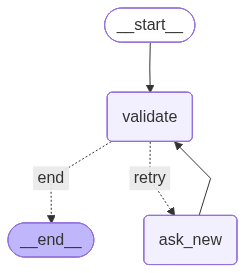

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Multi-Path Workflow

Different paths for different conditions

In [ ]:
class State(TypedDict):
    marks: int
    grade: str

def check_marks(state):
    return state

def route_grade(state):
    marks = state["marks"]
    if marks >= 80:
        return "A"
    elif marks >= 70:
        return "B"
    elif marks >= 60:
        return "C"
    elif marks >= 50:
        return "D"
    else:
        return "F"

def grade_a(state):
    state["grade"] = "A"
    return state

def grade_b(state):
    state["grade"] = "B"
    return state

def grade_c(state):
    state["grade"] = "C"
    return state

def grade_d(state):
    state["grade"] = "D"
    return state

def grade_f(state):
    state["grade"] = "F"
    return state

builder = StateGraph(State)
builder.add_node("check", check_marks)
builder.add_node("A", grade_a)
builder.add_node("B", grade_b)
builder.add_node("C", grade_c)
builder.add_node("D",grade_d)
builder.add_node("F", grade_f)
builder.add_edge(START, "check")

builder.add_conditional_edges(
    "check",
    route_grade,
    {
        "A": "A",
        "B": "B",
        "C": "C",
        "D": "D",
        "F": "F"
    }
)
builder.add_edge("A", END)
builder.add_edge("B", END)
builder.add_edge("C", END)
builder.add_edge("D", END)
builder.add_edge("F", END)

graph = builder.compile()

result = graph.invoke(
    {
        "marks": 65,
        "grade": ""
    }
)
print(result)

{'marks': 65, 'grade': 'C'}


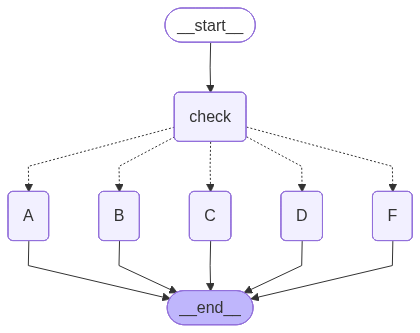

In [7]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Human in the loop

HITL is a design pattern where an AI system includes human judgment as part of the process. This approach allows you to pause an AI agent’s execution, wait for human review or input and then resume the process.

In [ ]:
class State(TypedDict):
    employee: str
    leave_days: int
    approved: bool
    status: str

def submit_request(state):
    print(f"\nEmployee: {state['employee']}")
    print(f"Days Requested: {state['leave_days']}")
    return state

def manager_review(state):
    decision = input("Approve leave? (yes/no): ")
    state["approved"] = (decision.lower() == "yes")
    return state

def route_review(state):
    if state["approved"]:
        return "approve"
    else:
        return "reject"
    
def approve_node(state):
    state["status"] = ("Leave Approved")
    return state

def reject_node(state):
    state["status"] = ("Leave Rejected")
    return state

builder = StateGraph(State)

builder.add_node("submit",submit_request)
builder.add_node("review",manager_review)
builder.add_node("approve",approve_node)
builder.add_node("reject",reject_node)

builder.add_edge(START,"submit")
builder.add_edge("submit","review")
builder.add_conditional_edges(
    "review",
    route_review,
    {
        "approve": "approve",
        "reject": "reject"
    }
)
builder.add_edge("approve",END)
builder.add_edge("reject",END)
graph = builder.compile()
result = graph.invoke(
    {
        "employee": "Sana",
        "leave_days": 3,
        "approved": False,
        "status": ""
    }
)
print(result)


Employee: Sana
Days Requested: 3
{'employee': 'Sana', 'leave_days': 3, 'approved': True, 'status': 'Leave Approved'}


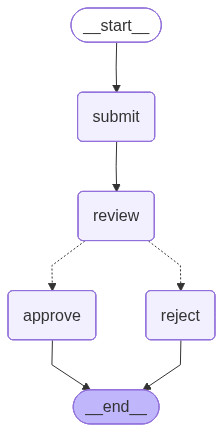

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))